<a href="https://colab.research.google.com/github/unVeroz007/KumpulTugas/blob/main/SpeechProcessing/2311532008_Muhammad_Galid_Avero_Code_Tugas_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install praat-parselmouth
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from scipy.signal import butter, filtfilt
import pandas as pd
import parselmouth

plt.rcParams['figure.figsize'] = (12, 4)

# Parameter untuk ekstraksi fitur
FRAME_MS = 25      # Durasi frame dalam milidetik
HOP_MS = 10        # Jarak antar frame dalam milidetik
N_MFCC = 13        # Jumlah koefisien MFCC
N_FFT = 2048       # Ukuran FFT
F_MIN = 75         # Frekuensi minimum untuk pitch (Hz)
F_MAX = 500        # Frekuensi maksimum untuk pitch (Hz)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 57.3 MB/s eta 0:00:00


#1. Load Audio

In [16]:
print("1. LOADING AUDIO")
nim_nama   = "2311432008_Muhammad Galid Avero"
AUDIO_PATH = f"/content/{nim_nama}-preprocessing.wav"

# Load audio dengan librosa
y, sr = librosa.load(AUDIO_PATH, sr=None)
durasi = len(y) / sr

print(f"   File audio   : {AUDIO_PATH}")
print(f"   Sampling rate: {sr} Hz")
print(f"   Durasi       : {durasi:.2f} detik")
print(f"   Jumlah sampel: {len(y)}")
print()

# Hitung ukuran frame dan hop dalam sampel
frame_size = int(FRAME_MS * sr / 1000)
hop_size = int(HOP_MS * sr / 1000)

print(f"Parameter framing:")
print(f"- Frame size   : {FRAME_MS} ms = {frame_size} samples")
print(f"- Hop size     : {HOP_MS} ms = {hop_size} samples")
print()

1. LOADING AUDIO
   File audio   : /content/2311432008_Muhammad Galid Avero-preprocessing.wav
   Sampling rate: 48000 Hz
   Durasi       : 77.66 detik
   Jumlah sampel: 3727872

Parameter framing:
- Frame size   : 25 ms = 1200 samples
- Hop size     : 10 ms = 480 samples



# 2. EKSTRAKSI MFCC (Mel-Frequency Cepstral Coefficients)


In [4]:
print("2. EKSTRAKSI MFCC")

# Ekstraksi MFCC
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=N_MFCC,
    n_fft=N_FFT,
    hop_length=hop_size,
    n_mels=40  # Jumlah mel filter banks
)

# MFCC delta (turunan pertama) - menangkap perubahan temporal
mfcc_delta = librosa.feature.delta(mfcc)

# MFCC delta-delta (turunan kedua) - menangkap akselerasi perubahan
mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

print(f"MFCC shape: {mfcc.shape}")
print(f"Jumlah koefisien MFCC: {N_MFCC}")
print(f"Jumlah frame: {mfcc.shape[1]}")
print()

# Siapkan DataFrame untuk MFCC
mfcc_data = []
for i in range(mfcc.shape[1]):
    row = {'frame': i}
    # MFCC statis
    for j in range(N_MFCC):
        row[f'mfcc_{j+1}'] = mfcc[j, i]
    # MFCC delta
    for j in range(N_MFCC):
        row[f'mfcc_delta_{j+1}'] = mfcc_delta[j, i]
    # MFCC delta-delta
    for j in range(N_MFCC):
        row[f'mfcc_delta2_{j+1}'] = mfcc_delta2[j, i]
    mfcc_data.append(row)

df_mfcc = pd.DataFrame(mfcc_data)

2. EKSTRAKSI MFCC
MFCC shape: (13, 7767)
Jumlah koefisien MFCC: 13
Jumlah frame: 7767



In [5]:
#Simpan ke CSV
csv_mfcc = f"{nim_nama}_MFCC.csv"
df_mfcc.to_csv(csv_mfcc, index=False)
print(f"MFCC disimpan ke: {csv_mfcc}")
print(f"Total kolom: {len(df_mfcc.columns)} (frame + {N_MFCC*3} koefisien)")
print()

MFCC disimpan ke: 2311432008_Muhammad Galid Avero_MFCC.csv
Total kolom: 40 (frame + 39 koefisien)



Visualisasi MFCC disimpan ke: 2311432008_Muhammad Galid Avero_MFCC_visualisasi.png



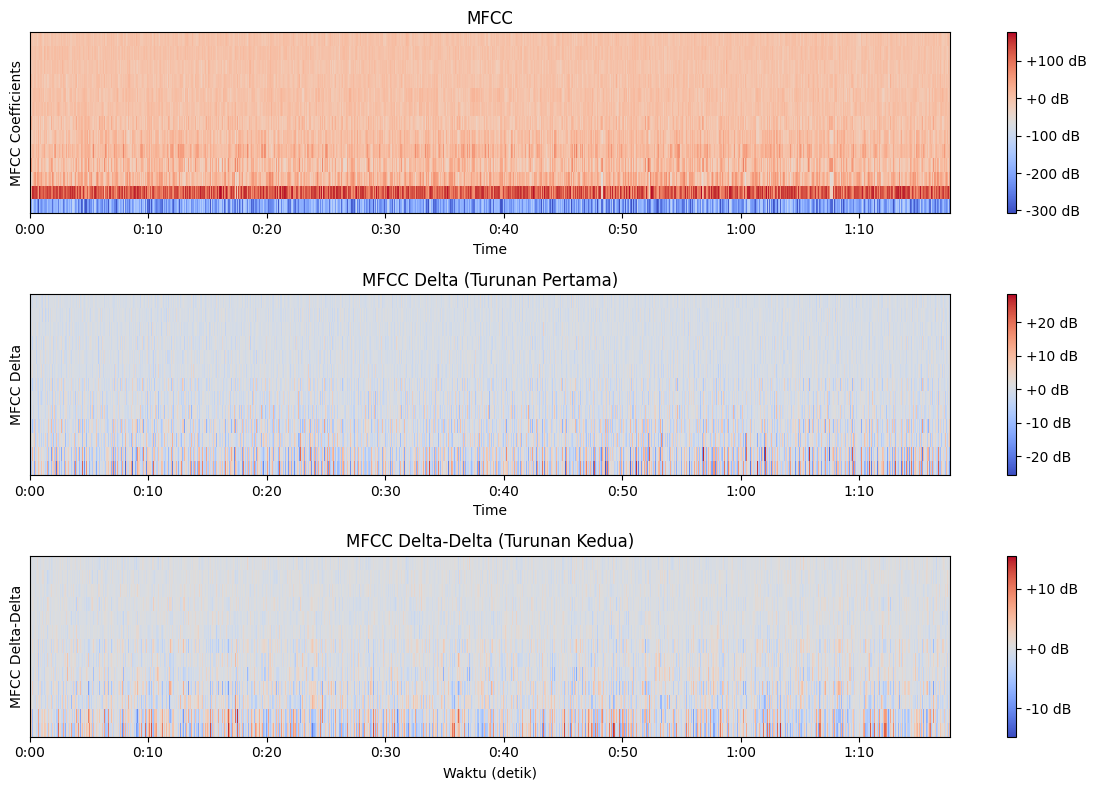

In [6]:
# Visualisasi MFCC
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
librosa.display.specshow(mfcc, sr=sr, hop_length=hop_size, x_axis='time')
plt.colorbar(format='%+2.0f dB')
plt.title('MFCC')
plt.ylabel('MFCC Coefficients')

plt.subplot(3, 1, 2)
librosa.display.specshow(mfcc_delta, sr=sr, hop_length=hop_size, x_axis='time')
plt.colorbar(format='%+2.0f dB')
plt.title('MFCC Delta (Turunan Pertama)')
plt.ylabel('MFCC Delta')

plt.subplot(3, 1, 3)
librosa.display.specshow(mfcc_delta2, sr=sr, hop_length=hop_size, x_axis='time')
plt.colorbar(format='%+2.0f dB')
plt.title('MFCC Delta-Delta (Turunan Kedua)')
plt.ylabel('MFCC Delta-Delta')
plt.xlabel('Waktu (detik)')

plt.tight_layout()
plt.savefig(f'{nim_nama}_MFCC_visualisasi.png', dpi=150, bbox_inches='tight')
print(f"Visualisasi MFCC disimpan ke: {nim_nama}_MFCC_visualisasi.png")
print()

# 3. EKSTRAKSI PITCH (F0 - Fundamental Frequency)


In [8]:
print("3. EKSTRAKSI PITCH (F0)")

# Import call function from parselmouth
from parselmouth.praat import call

# Load audio dengan Parselmouth
snd = parselmouth.Sound(AUDIO_PATH)

# Ekstraksi pitch menggunakan metode autocorrelation (algoritme Praat)
pitch = call(snd, "To Pitch", 0.0, F_MIN, F_MAX)

# Ekstrak nilai pitch untuk setiap frame
pitch_values = []
time_points = []

# Tentukan waktu untuk setiap frame (berdasarkan hop_size dari MFCC agar sinkron)
num_frames_mfcc = mfcc.shape[1]
for i in range(num_frames_mfcc):
    t = i * hop_size / sr
    time_points.append(t)

    # Dapatkan nilai F0 pada waktu t
    f0 = call(pitch, "Get value at time", t, 'Hertz', 'Linear')

    # Jika undefined (unvoiced), set ke 0
    if np.isnan(f0) or f0 is None:
        f0 = 0.0

    pitch_values.append(f0)

pitch_values = np.array(pitch_values)

print(f"Jumlah frame: {len(pitch_values)}")
print(f"Pitch range: {F_MIN}-{F_MAX} Hz")
print(f"Mean F0 (voiced frames): {pitch_values[pitch_values > 0].mean():.2f} Hz" if np.any(pitch_values > 0) else "   Mean F0 (voiced frames): 0 Hz")
print(f"Std F0 (voiced frames): {pitch_values[pitch_values > 0].std():.2f} Hz" if np.any(pitch_values > 0) else "   Std F0 (voiced frames): 0 Hz")
print(f"Voiced frames: {np.sum(pitch_values > 0)} ({100*np.sum(pitch_values > 0)/len(pitch_values):.1f}%)")
print()

3. EKSTRAKSI PITCH (F0)
Jumlah frame: 7767
Pitch range: 75-500 Hz
Mean F0 (voiced frames): 155.41 Hz
Std F0 (voiced frames): 36.60 Hz
Voiced frames: 6590 (84.8%)



In [9]:
# Siapkan DataFrame untuk Pitch
df_pitch = pd.DataFrame({
    'frame': range(len(pitch_values)),
    'time_sec': time_points,
    'f0_hz': pitch_values,
    'is_voiced': (pitch_values > 0).astype(int)
})

# Simpan ke CSV
csv_pitch = f"{nim_nama}_Pitch.csv"
df_pitch.to_csv(csv_pitch, index=False)
print(f"Pitch disimpan ke: {csv_pitch}")
print()

Pitch disimpan ke: 2311432008_Muhammad Galid Avero_Pitch.csv



Visualisasi Pitch disimpan ke: 2311432008_Muhammad Galid Avero_Pitch_visualisasi.png



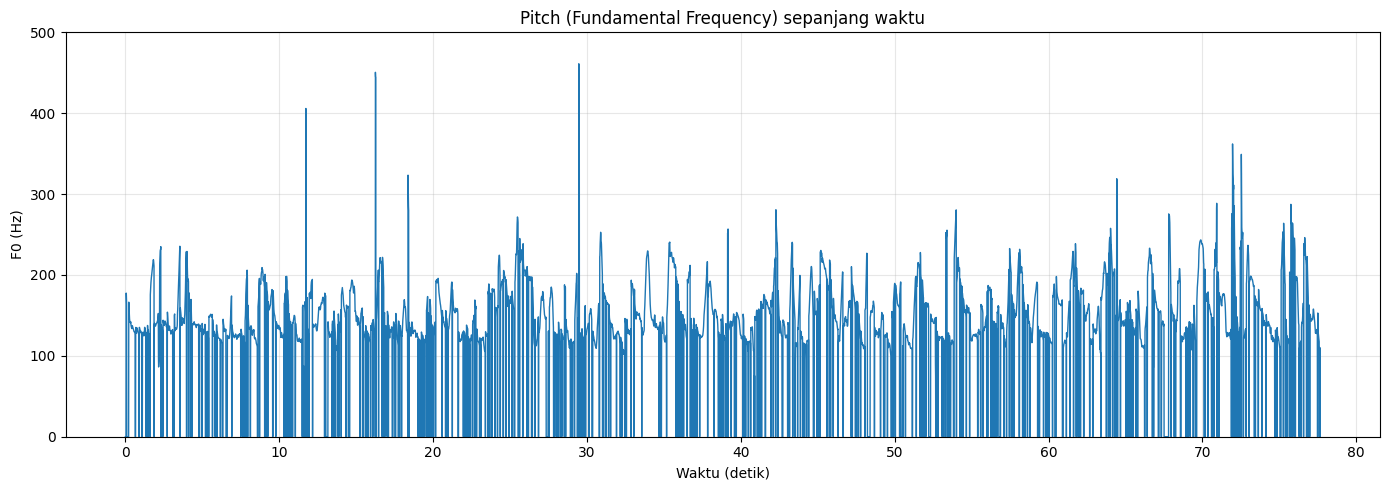

In [10]:
# Visualisasi Pitch
plt.figure(figsize=(14, 5))
plt.plot(time_points, pitch_values, linewidth=1)
plt.xlabel('Waktu (detik)')
plt.ylabel('F0 (Hz)')
plt.title('Pitch (Fundamental Frequency) sepanjang waktu')
plt.grid(True, alpha=0.3)
plt.ylim(0, F_MAX)
plt.tight_layout()
plt.savefig(f'{nim_nama}_Pitch_visualisasi.png', dpi=150, bbox_inches='tight')
print(f"Visualisasi Pitch disimpan ke: {nim_nama}_Pitch_visualisasi.png")
print()

# 4. EKSTRAKSI FORMANT (F1, F2, F3)


In [11]:
print("4. EKSTRAKSI FORMANT (F1, F2, F3)")
# Ekstraksi formant menggunakan Praat
# Parameter: time_step=0.0 (auto), max_num_formants=5, max_formant=5500 Hz
formant = call(snd, "To Formant (burg)", 0.0, 5, 5500, 0.025, 50)

# Ekstrak F1, F2, F3 untuk setiap frame
f1_values = []
f2_values = []
f3_values = []

# Samakan jumlah frame dengan time_points agar tidak error saat pembuatan DataFrame
num_frames_target = len(time_points)

for i in range(num_frames_target):
    t = time_points[i]

    # Ekstrak formant 1, 2, 3
    f1 = call(formant, "Get value at time", 1, t, 'Hertz', 'Linear')
    f2 = call(formant, "Get value at time", 2, t, 'Hertz', 'Linear')
    f3 = call(formant, "Get value at time", 3, t, 'Hertz', 'Linear')

    # Handle undefined values
    f1 = 0.0 if np.isnan(f1) or f1 is None else f1
    f2 = 0.0 if np.isnan(f2) or f2 is None else f2
    f3 = 0.0 if np.isnan(f3) or f3 is None else f3

    f1_values.append(f1)
    f2_values.append(f2)
    f3_values.append(f3)

f1_values = np.array(f1_values)
f2_values = np.array(f2_values)
f3_values = np.array(f3_values)

print(f"  Jumlah frame: {len(f1_values)}")
print(f"  F1 mean (voiced): {f1_values[f1_values > 0].mean():.2f} Hz" if np.any(f1_values > 0) else "   F1 mean: 0 Hz")
print(f"  F2 mean (voiced): {f2_values[f2_values > 0].mean():.2f} Hz" if np.any(f2_values > 0) else "   F2 mean: 0 Hz")
print(f"  F3 mean (voiced): {f3_values[f3_values > 0].mean():.2f} Hz" if np.any(f3_values > 0) else "   F3 mean: 0 Hz")
print()

# Siapkan DataFrame untuk Formant
df_formant = pd.DataFrame({
    'frame': range(len(f1_values)),
    'time_sec': time_points,
    'f1_hz': f1_values,
    'f2_hz': f2_values,
    'f3_hz': f3_values,
    'is_voiced': ((f1_values > 0) & (f2_values > 0) & (f3_values > 0)).astype(int)
})

4. EKSTRAKSI FORMANT (F1, F2, F3)
  Jumlah frame: 7767
  F1 mean (voiced): 524.34 Hz
  F2 mean (voiced): 1526.97 Hz
  F3 mean (voiced): 2504.35 Hz



Formant disimpan ke: 2311432008_Muhammad Galid Avero_Formant.csv

Visualisasi Formant disimpan ke: 2311432008_Muhammad Galid Avero_Formant_visualisasi.png



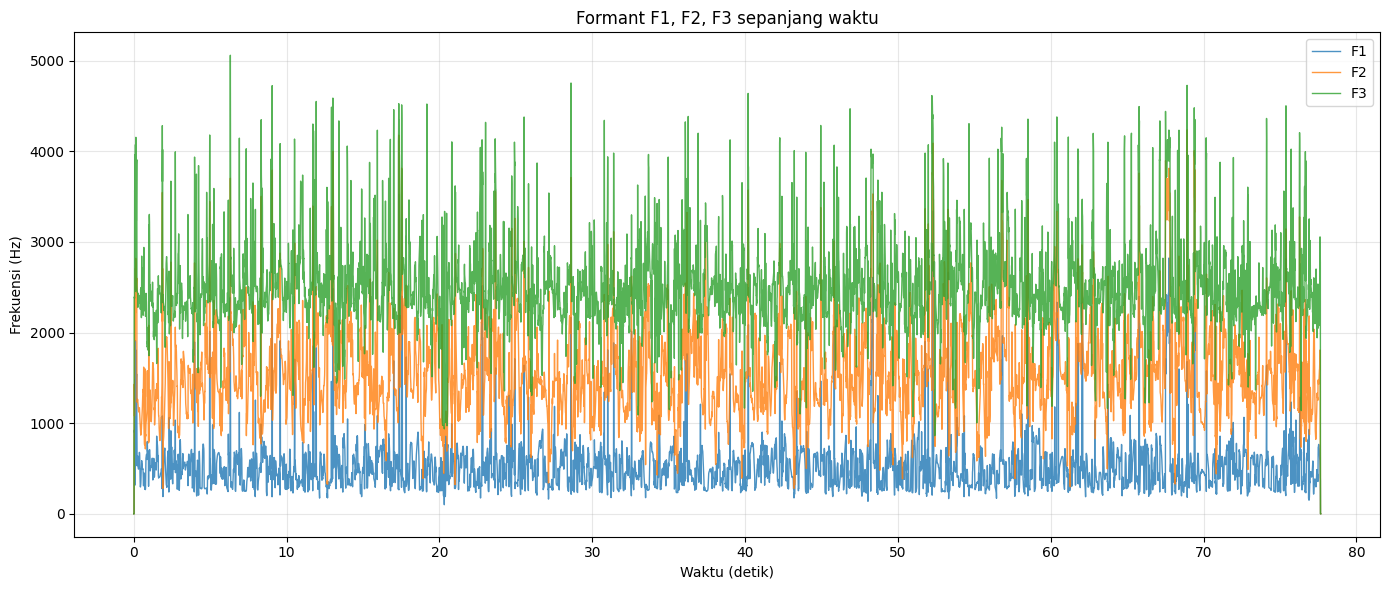

In [12]:
# Simpan ke CSV
csv_formant = f"{nim_nama}_Formant.csv"
df_formant.to_csv(csv_formant, index=False)
print(f"Formant disimpan ke: {csv_formant}")
print()

# Visualisasi Formant
plt.figure(figsize=(14, 6))
plt.plot(time_points, f1_values, label='F1', linewidth=1, alpha=0.8)
plt.plot(time_points, f2_values, label='F2', linewidth=1, alpha=0.8)
plt.plot(time_points, f3_values, label='F3', linewidth=1, alpha=0.8)
plt.xlabel('Waktu (detik)')
plt.ylabel('Frekuensi (Hz)')
plt.title('Formant F1, F2, F3 sepanjang waktu')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{nim_nama}_Formant_visualisasi.png', dpi=150, bbox_inches='tight')
print(f"Visualisasi Formant disimpan ke: {nim_nama}_Formant_visualisasi.png")
print()

# 5. EKSTRAKSI PROSODI (Statis dan Dinamis)


In [13]:
print("5. EKSTRAKSI PROSODI")
# 5.1 Intensity (Energi/Loudness)
intensity = call(snd, "To Intensity", F_MIN, 0.0, "yes")

# Gunakan jumlah frame yang konsisten dengan MFCC/Pitch
num_frames_target = len(time_points)

intensity_values = []
for i in range(num_frames_target):
    t = time_points[i]
    intens = call(intensity, "Get value at time", t, 'Cubic')
    intens = 0.0 if np.isnan(intens) or intens is None else intens
    intensity_values.append(intens)

intensity_values = np.array(intensity_values)

# 5.2 Hitung fitur prosodi dinamis
delta_f0 = np.diff(pitch_values, prepend=pitch_values[0])
delta_intensity = np.diff(intensity_values, prepend=intensity_values[0])

# 5.3 Jitter (variasi pitch periode-ke-periode)
jitter_local = []
window_size = 5
for i in range(num_frames_target):
    start = max(0, i - window_size // 2)
    end = min(num_frames_target, i + window_size // 2 + 1)
    window = pitch_values[start:end]
    voiced_window = window[window > 0]

    if len(voiced_window) > 1:
        jitter = np.mean(np.abs(np.diff(voiced_window))) / np.mean(voiced_window) * 100
    else:
        jitter = 0.0
    jitter_local.append(jitter)

jitter_local = np.array(jitter_local)

# 5.4 Shimmer (variasi amplitudo periode-ke-periode)
shimmer_local = []
for i in range(num_frames_target):
    start = max(0, i - window_size // 2)
    end = min(num_frames_target, i + window_size // 2 + 1)
    window = intensity_values[start:end]
    voiced_window = window[window > 0]

    if len(voiced_window) > 1:
        shimmer = np.mean(np.abs(np.diff(voiced_window))) / np.mean(voiced_window) * 100
    else:
        shimmer = 0.0
    shimmer_local.append(shimmer)

shimmer_local = np.array(shimmer_local)

5. EKSTRAKSI PROSODI


In [14]:
# 5.5 Speaking rate (estimasi kecepatan bicara)
# Hitung berdasarkan jumlah perubahan voicing dalam window waktu tertentu
speaking_rate = []
rate_window = 50  # window untuk estimasi speaking rate

# Gunakan jumlah frame dari time_points agar konsisten
num_frames_target = len(time_points)

for i in range(num_frames_target):
    start = max(0, i - rate_window // 2)
    end = min(num_frames_target, i + rate_window // 2 + 1)
    voiced = (pitch_values[start:end] > 0).astype(int)
    # Hitung jumlah transisi voiced-unvoiced
    transitions = np.sum(np.abs(np.diff(voiced)))
    speaking_rate.append(transitions)

speaking_rate = np.array(speaking_rate)

print(f"  Jumlah frame: {num_frames_target}")
print(f"   Fitur Statis:")
print(f"   - F0 mean: {pitch_values[pitch_values > 0].mean():.2f} Hz" if np.any(pitch_values > 0) else "   - F0 mean: 0 Hz")
print(f"   - Intensity mean: {intensity_values[intensity_values > 0].mean():.2f} dB" if np.any(intensity_values > 0) else "   - Intensity mean: 0 dB")
print(f"   Fitur Dinamis:")
print(f"   - Delta F0 mean: {delta_f0.mean():.2f} Hz")
print(f"   - Delta Intensity mean: {delta_intensity.mean():.2f} dB")
print(f"   - Jitter mean: {jitter_local[jitter_local > 0].mean():.2f}%" if np.any(jitter_local > 0) else "   - Jitter mean: 0%")
print(f"   - Shimmer mean: {shimmer_local[shimmer_local > 0].mean():.2f}%" if np.any(shimmer_local > 0) else "   - Shimmer mean: 0%")
print()

# Siapkan DataFrame untuk Prosodi
df_prosodi = pd.DataFrame({
    'frame': range(num_frames_target),
    'time_sec': time_points,
    # Fitur Statis
    'f0_hz': pitch_values,
    'intensity_db': intensity_values,
    'speaking_rate': speaking_rate,
    # Fitur Dinamis
    'delta_f0_hz': delta_f0,
    'delta_intensity_db': delta_intensity,
    'jitter_percent': jitter_local,
    'shimmer_percent': shimmer_local,
    'is_voiced': (pitch_values > 0).astype(int)
})

# Simpan ke CSV
csv_prosodi = f"{nim_nama}_Prosodi.csv"
df_prosodi.to_csv(csv_prosodi, index=False)
print(f" Prosodi disimpan ke: {csv_prosodi}")
print()

  Jumlah frame: 7767
   Fitur Statis:
   - F0 mean: 155.41 Hz
   - Intensity mean: 68.31 dB
   Fitur Dinamis:
   - Delta F0 mean: -0.00 Hz
   - Delta Intensity mean: 0.00 dB
   - Jitter mean: 2.07%
   - Shimmer mean: 2.57%

 Prosodi disimpan ke: 2311432008_Muhammad Galid Avero_Prosodi.csv



Visualisasi Prosodi disimpan ke: 2311432008_Muhammad Galid Avero_Prosodi_visualisasi.png



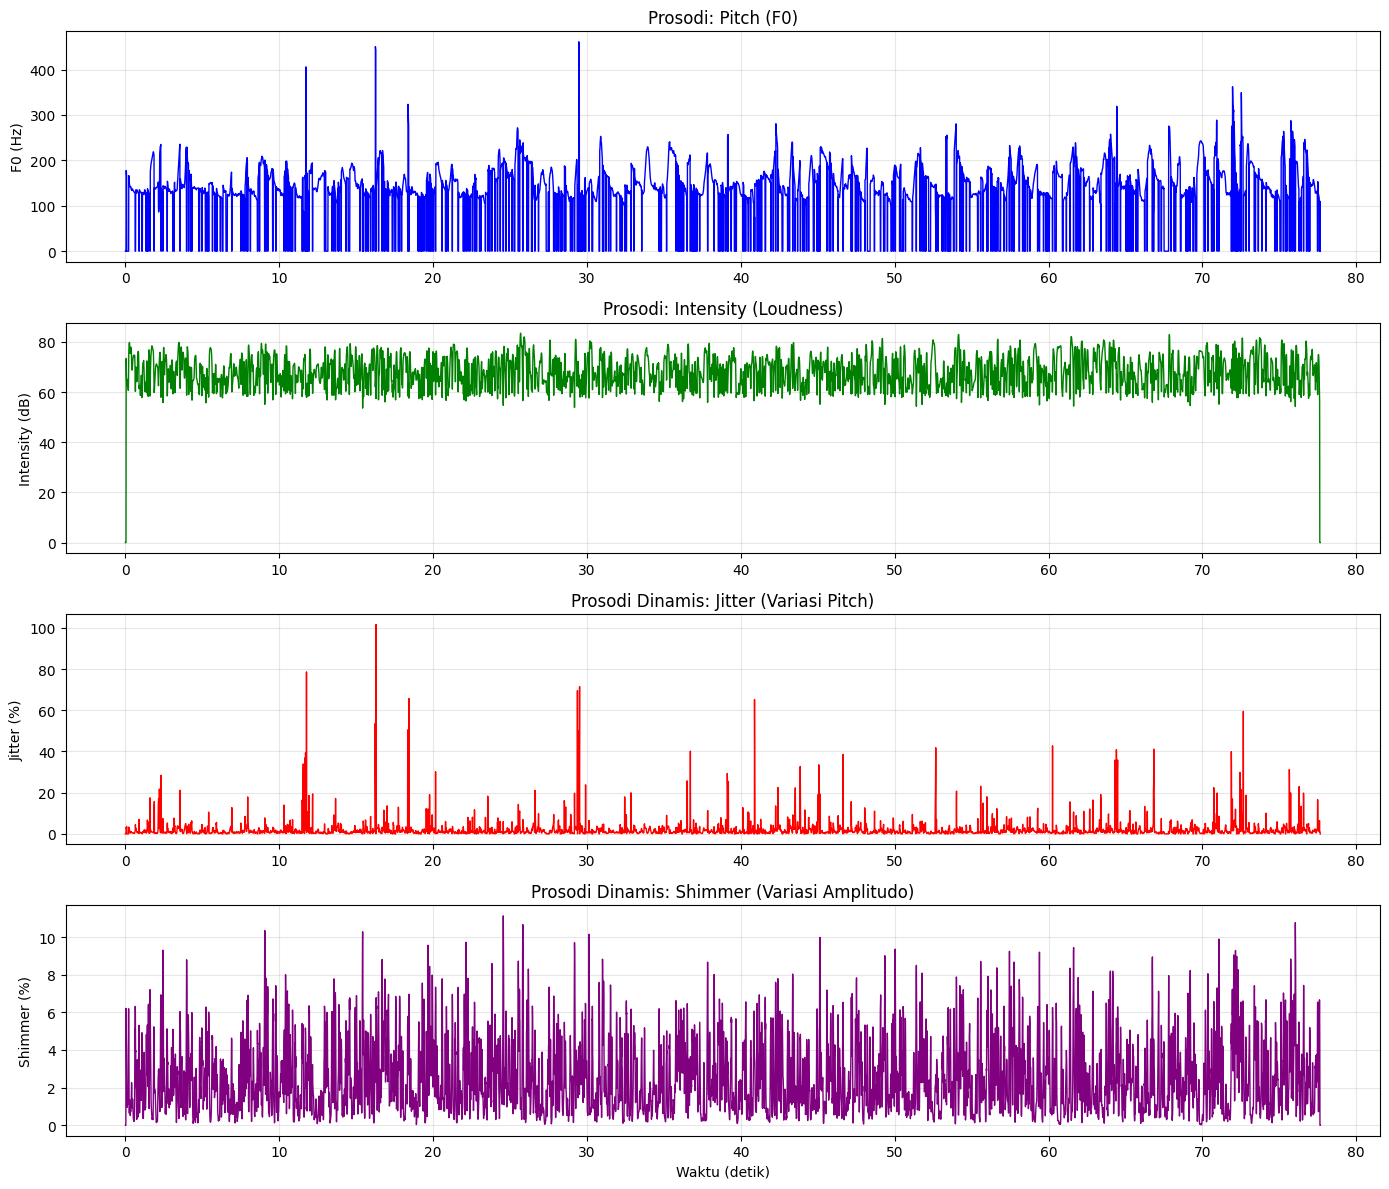

In [15]:
# Visualisasi Prosodi
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Plot F0
axes[0].plot(time_points, pitch_values, linewidth=1, color='blue')
axes[0].set_ylabel('F0 (Hz)')
axes[0].set_title('Prosodi: Pitch (F0)')
axes[0].grid(True, alpha=0.3)

# Plot Intensity
axes[1].plot(time_points, intensity_values, linewidth=1, color='green')
axes[1].set_ylabel('Intensity (dB)')
axes[1].set_title('Prosodi: Intensity (Loudness)')
axes[1].grid(True, alpha=0.3)

# Plot Jitter
axes[2].plot(time_points, jitter_local, linewidth=1, color='red')
axes[2].set_ylabel('Jitter (%)')
axes[2].set_title('Prosodi Dinamis: Jitter (Variasi Pitch)')
axes[2].grid(True, alpha=0.3)

# Plot Shimmer
axes[3].plot(time_points, shimmer_local, linewidth=1, color='purple')
axes[3].set_ylabel('Shimmer (%)')
axes[3].set_xlabel('Waktu (detik)')
axes[3].set_title('Prosodi Dinamis: Shimmer (Variasi Amplitudo)')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{nim_nama}_Prosodi_visualisasi.png', dpi=150, bbox_inches='tight')
print(f"Visualisasi Prosodi disimpan ke: {nim_nama}_Prosodi_visualisasi.png")
print()